<a href="https://colab.research.google.com/github/krish3453/Machine_Learning/blob/main/Standardisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [12]:
import kagglehub
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

100%|██████████| 3.27k/3.27k [00:00<00:00, 4.01MB/s]

Extracting files...


In [15]:
import os
print(os.listdir(path))

['Social_Network_Ads.csv']


In [18]:
file_path = os.path.join(path, 'Social_Network_Ads.csv')
df = pd.read_csv(file_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [25]:
df=df.iloc[:,2:]
df.sample(5)

,Age,EstimatedSalary,Purchased
288,41,79000,0
355,60,34000,1
319,36,60000,0
224,35,60000,0
194,28,89000,0


<h1>Train-Test</h1>

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),
                                               df['Purchased'],
                                               test_size=0.3,
                                               random_state=0)
X_train.shape,X_test.shape

((280, 2), (120, 2))

In [28]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [29]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [30]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


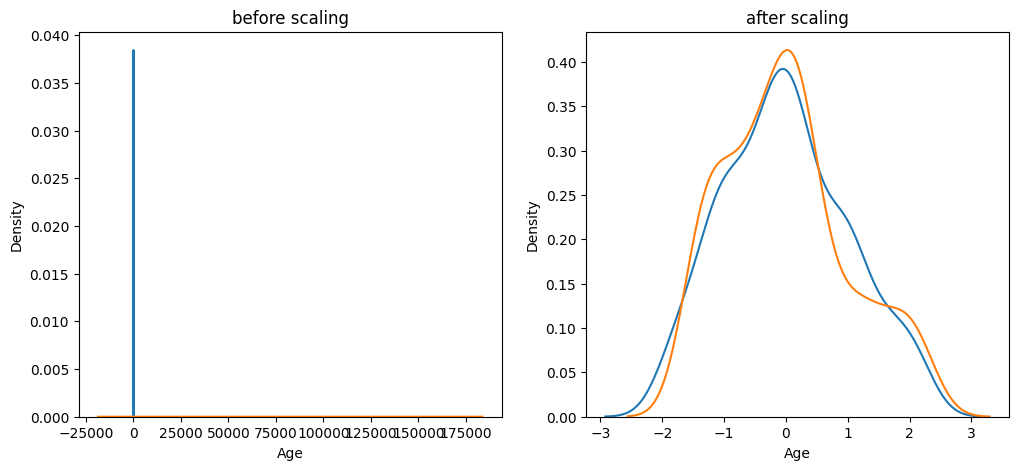

In [34]:

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

#before scaling
ax1.set_title('before scaling')
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

#after scaling
ax2.set_title('after scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()



<h1>Comparison of distribution</h1>

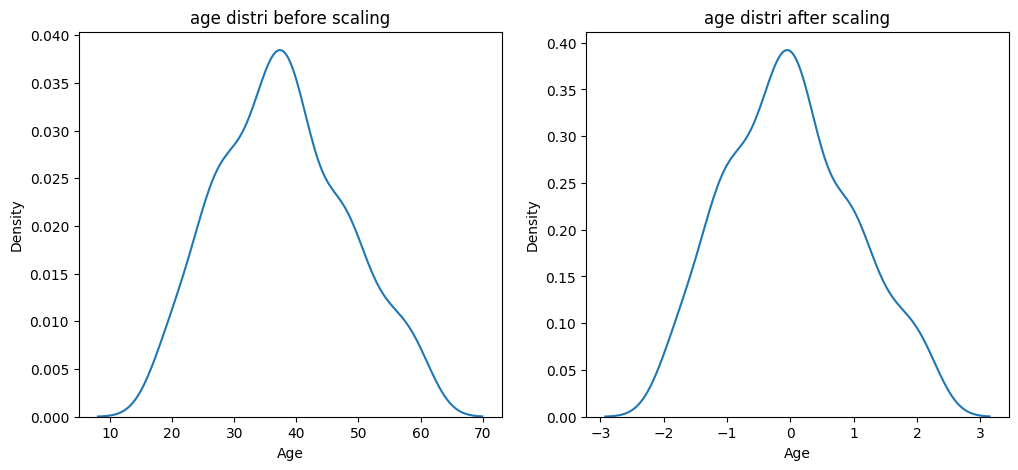

In [35]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

#before scaling
ax1.set_title('age distri before scaling')
sns.kdeplot(X_train['Age'],ax=ax1)

#after scaling
ax2.set_title('age distri after scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
plt.show()

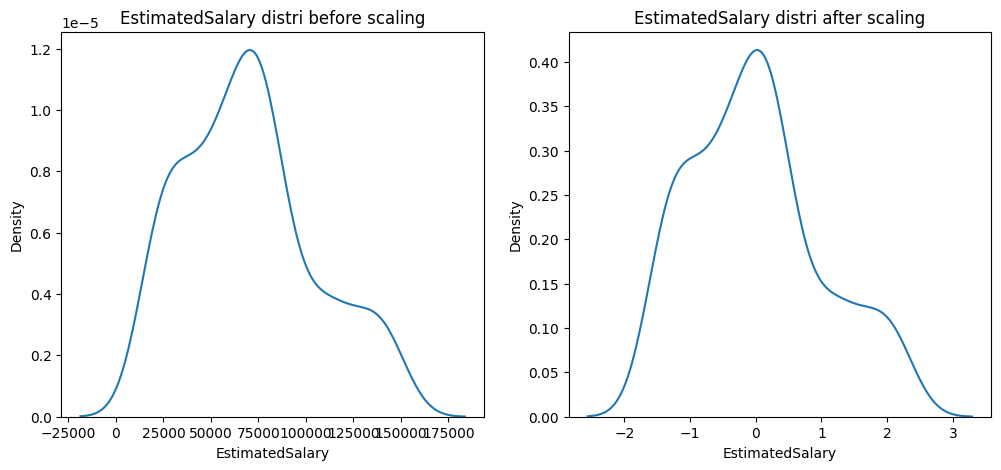

In [37]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

#before scaling
ax1.set_title('EstimatedSalary distri before scaling')
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

#after scaling
ax2.set_title('EstimatedSalary distri after scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()